# PD Summary — One-shot QC + Plots

This notebook is designed to be **run top-to-bottom** and then shared (export to HTML/PDF if desired).

It will:
1) explain the expected input format
2) load all `*_summary.csv` / `*_collapsed_summary.csv` in the PD folder
3) show quick tables + QC plots
4) (optionally) save plots and key summary tables to a local `Outputs/` folder

## Data location
This notebook reads from `WILSONTEW_PD_FOLDER` if set; otherwise it falls back to `./PD_Data`.
Current recommended PD folder (from your setup):
- `C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/Sequencing/PD Data`

In [2]:
suppressPackageStartupMessages({
  library(tidyverse)
})


## Expected columns (typical)
Most PD summary CSVs include columns like:
- `batch`, `time_point`, `DSB`, `allele`, `combo`, `cis_trans`, `count`
Optional but supported:
- `repeat` (e.g., INTACT/SSA)
- `replicate`
- `alignment_name`

If any optional columns are missing, we will add reasonable defaults.

In [3]:
# ---- Locate PD folder ----
pd_folder <- Sys.getenv('WILSONTEW_PD_FOLDER', unset = file.path(getwd(), 'PD_Data'))
pd_folder <- normalizePath(pd_folder, winslash = '/', mustWork = FALSE)
dir.create(pd_folder, recursive = TRUE, showWarnings = FALSE)
message('Using pd_folder: ', pd_folder)

files <- list.files(pd_folder, pattern = '(_summary|_collapsed_summary)\\.csv$', full.names = TRUE)
if (length(files) == 0) {
  stop(paste0(
    'No *_summary.csv or *_collapsed_summary.csv files found in pd_folder: ', pd_folder,
    '\n\nFix: copy the PD summary CSVs into that folder, or set WILSONTEW_PD_FOLDER to the directory that contains them.'
  ))
}
message('Found ', length(files), ' file(s).')
head(files, 10)

Using pd_folder: C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/Sequencing/PD Data

Found 4 file(s).



[1] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/Sequencing/PD Data/batch6_T0_PD_UMI_plus_singletons_collapsed_summary.csv"  
[2] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/Sequencing/PD Data/batch6_T180_PD_UMI_plus_singletons_collapsed_summary.csv"
[3] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/Sequencing/PD Data/batch8_T0_PD_UMI_plus_singletons_collapsed_summary.csv"  
[4] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/Sequencing/PD Data/batch8_T180_PD_UMI_plus_singletons_collapsed_summary.csv"

In [8]:
# ---- Read and combine ----
read_one <- function(f) {
  dat <- readr::read_csv(f, show_col_types = FALSE)
  if (!("repeat" %in% names(dat))) dat <- dplyr::mutate(dat, `repeat` = "ALL")
  if (!("replicate" %in% names(dat))) dat <- dplyr::mutate(dat, replicate = "ALL")
  if (!("alignment_name" %in% names(dat))) dat <- dplyr::mutate(dat, alignment_name = NA_character_)
  dat <- dplyr::mutate(
    dat,
    source_path = f,
    source_dir = dirname(f),
    allele = as.character(.data[["allele"]]),
    combo = as.character(.data[["combo"]]),
    cis_trans = as.character(.data[["cis_trans"]]),
    DSB = as.character(.data[["DSB"]]),
    `repeat` = as.character(.data[["repeat"]]),
    replicate = as.character(.data[["replicate"]]),
    batch = as.character(.data[["batch"]])
  )
  dat
}

dat_raw <- purrr::map_dfr(files, read_one)
dat_raw <- dplyr::mutate(dat_raw, batch = factor(batch, levels = sort(unique(batch))))
dplyr::glimpse(dat_raw)

Rows: 659
Columns: 13
$ batch          <fct> 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6…
$ DSB2_loci      <chr> "chr4", "chr4", "chr4", "chr4", "chr4", "chr4", "chr4",…
$ time_point     <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ replicate      <chr> "1", "1", "1", "1", "1", "1", "1", "1", "1", "1", "1", …
$ alignment_name <chr> "CIS_DSB1_FULL_CHRIII_L02", "CIS_DSB1_FULL_CHRIII_L03",…
$ cis_trans      <chr> "CIS", "CIS", "CIS", "CIS", "CIS", "CIS", "CIS", "CIS",…
$ DSB            <chr> "DSB1", "DSB1", "DSB1", "DSB1", "DSB1", "DSB1", "DSB1",…
$ combo          <chr> "A_to_B", "A_to_B", "A_to_B", "A_to_B", "A_to_B", "A_to…
$ `repeat`       <chr> "INTACT", "INTACT", "INTACT", "INTACT", "INTACT", "INTA…
$ allele         <chr> "CHRIII_L02", "CHRIII_L03", "CHRIII_L04", "CHRIV_L01", …
$ count          <dbl> 51283, 38174, 228463, 49541, 32857, 54088, 39551, 44777…
$ source_path    <chr> "C:/Users/dunnmk/University of Michigan Dropbox/MED-WIL…
$ source_dir     <

In [9]:
# ---- Quick sanity tables ----
dat_raw %>%
  count(batch, time_point, DSB, sort = TRUE, name = 'n_rows') %>%
  head(30)


batch,time_point,DSB,n_rows
<fct>,<dbl>,<chr>,<int>
6,180,TRANS,80
8,180,TRANS,79
6,0,TRANS,57
6,0,DSB1,52
6,180,DSB1,52
6,180,DSB2,52
8,0,DSB1,52
8,180,DSB1,52
8,180,DSB2,52


## QC plots
These plots are meant to answer: “Does the data look sane?” before doing any deeper analysis.

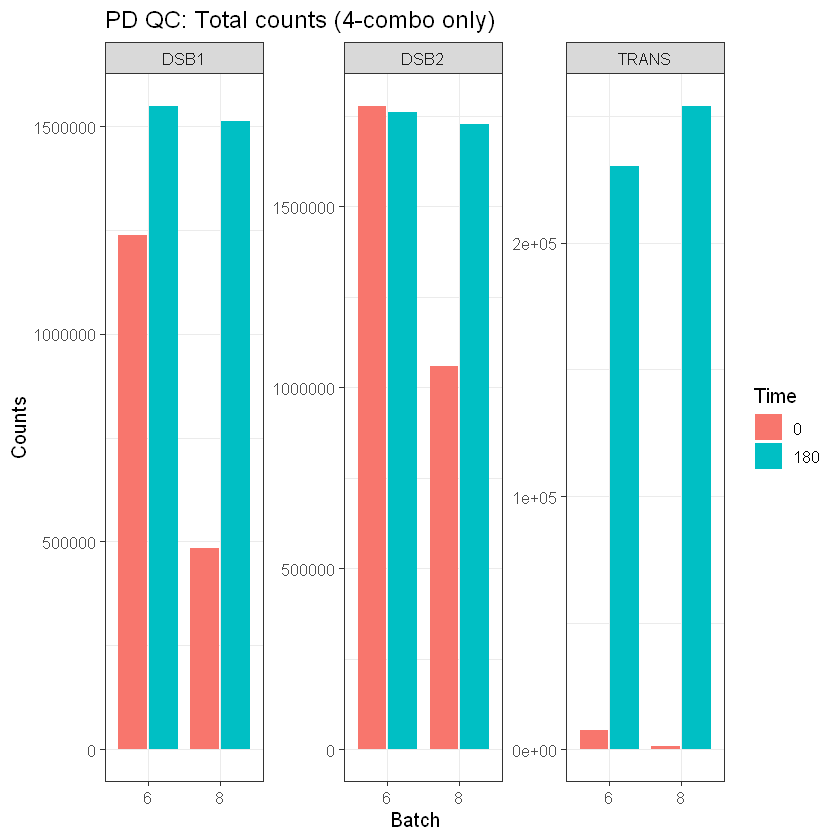

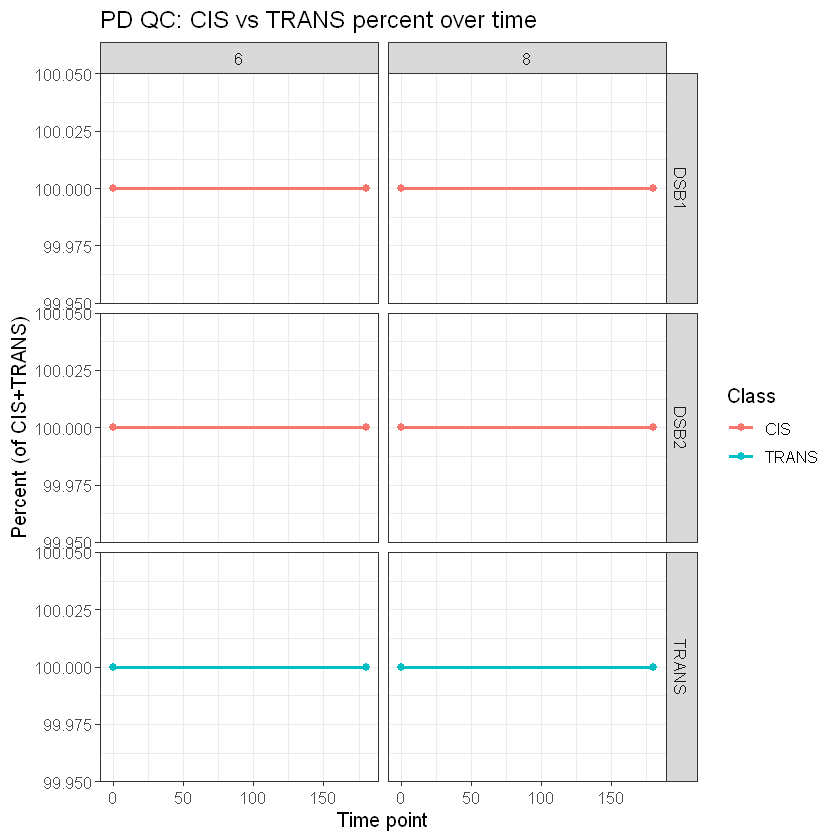

In [10]:
combos_4 <- c('A_to_B', 'C_to_D', 'A_to_D', 'C_to_B')
cis_combos <- c('A_to_B', 'C_to_D')
trans_combos <- c('A_to_D', 'C_to_B')

dat4 <- dat_raw %>% filter(combo %in% combos_4)

# Total counts per group (raw counts; good for QC)
qc_totals <- dat4 %>%
  group_by(batch, time_point, DSB) %>%
  summarise(Total_Counts = sum(count, na.rm = TRUE), .groups = 'drop')

p_total <- ggplot(qc_totals, aes(x = batch, y = Total_Counts, fill = factor(time_point))) +
  geom_col(position = position_dodge(width = 0.85), width = 0.8) +
  facet_wrap(~ DSB, scales = 'free_y') +
  theme_bw(base_size = 12) +
  labs(title = 'PD QC: Total counts (4-combo only)', x = 'Batch', y = 'Counts', fill = 'Time')
print(p_total)

# CIS/TRANS percent over time (computed from combo sums)
qc_cistrans <- dat4 %>%
  mutate(class = case_when(combo %in% cis_combos ~ 'CIS', combo %in% trans_combos ~ 'TRANS', TRUE ~ 'OTHER')) %>%
  group_by(batch, time_point, DSB, class) %>%
  summarise(Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(batch, time_point, DSB) %>%
  mutate(Percent = if_else(sum(Counts, na.rm = TRUE) > 0, 100 * Counts / sum(Counts, na.rm = TRUE), NA_real_)) %>%
  ungroup()

p_cistrans <- ggplot(qc_cistrans, aes(x = as.numeric(as.character(time_point)), y = Percent, color = class)) +
  geom_line(linewidth = 1.1) +
  geom_point(size = 2) +
  facet_grid(DSB ~ batch) +
  theme_bw(base_size = 12) +
  labs(title = 'PD QC: CIS vs TRANS percent over time', x = 'Time point', y = 'Percent (of CIS+TRANS)', color = 'Class')
print(p_cistrans)

In [11]:
# ---- Optional: save plots for sharing ----
out_dir <- file.path(getwd(), 'Outputs', 'PD')
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
ggsave(filename = file.path(out_dir, 'PD_QC_total_counts.png'), plot = p_total, width = 12, height = 6, dpi = 200)
ggsave(filename = file.path(out_dir, 'PD_QC_cis_trans_percent.png'), plot = p_cistrans, width = 14, height = 8, dpi = 200)
message('Saved plots to: ', out_dir)

Saved plots to: c:/Users/dunnmk/wilsontew-data-analysis/Outputs/PD

